### Working on a heart disease dataset and to find the best amoungs KNN, naive bias and logistice Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"E:\sculptsoft\19 June\heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Using boxplot method to detect outliers 

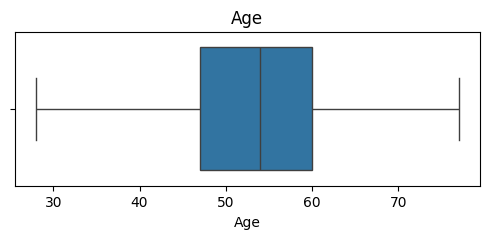

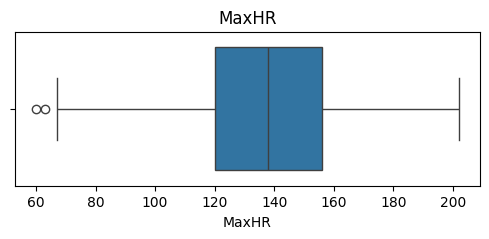

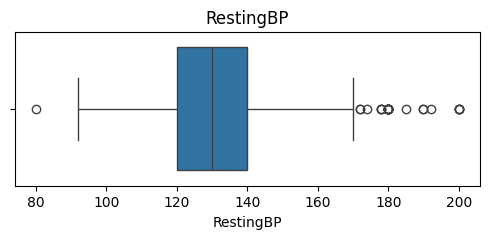

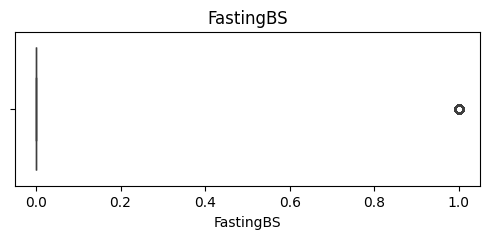

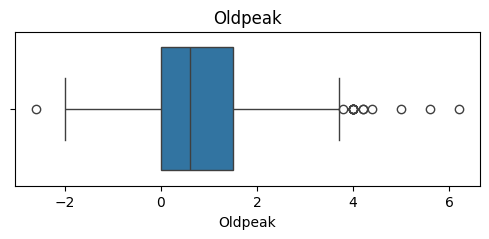

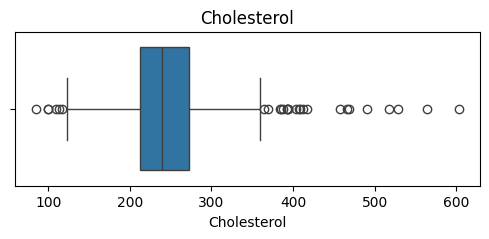

In [28]:
numerical_col = {
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "FastingBS"
}

for col in numerical_col:
    plt.figure(figsize = ((6,2)))
    sns.boxplot(x = df[col], vert = False)
    plt.title(col)
    plt.show()

In [12]:
print((df['RestingBP'] == 0).sum())
print((df['Cholesterol'] == 0).sum())

1
172


### Removing the single row of 0 restingBP (BP between 175-200 is practically possible if having some disease)

In [14]:
df = df[df["RestingBP"]>0]

### Analying the 172 zero values in Cholesterol

In [19]:
df_zero_chol = df[df['Cholesterol'] == 0]
df_zero_chol.head(10)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
298,51,M,ASY,110,0,1,Normal,92,N,0.0,Flat,1
299,47,M,ASY,110,0,1,ST,149,N,2.1,Up,1
300,60,M,ASY,160,0,1,Normal,149,N,0.4,Flat,1
301,55,M,ATA,140,0,0,ST,150,N,0.2,Up,0
302,53,M,ASY,125,0,1,Normal,120,N,1.5,Up,1


In [20]:
df_zero_chol["HeartDisease"].value_counts()

HeartDisease
1    151
0     20
Name: count, dtype: int64

### Using KNNImputer because we cannot directly impute the median or mean in cholesterol as there is high count of positives in it 

In [46]:
from sklearn.impute import KNNImputer

df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
columns_for_imputation = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol']
df_numeric = df[columns_for_imputation]
imputer = KNNImputer(n_neighbors=5)
df_filled = pd.DataFrame(imputer.fit_transform(df_numeric), columns=columns_for_imputation)
df["Cholesterol"] = df_filled["Cholesterol"]


C:\Users\Pratham Langaliya\AppData\Local\Temp\ipykernel_26608\1734513888.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
C:\Users\Pratham Langaliya\AppData\Local\Temp\ipykernel_26608\1734513888.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cholesterol"] = df_filled["Cholesterol"]


<Axes: xlabel='Cholesterol'>

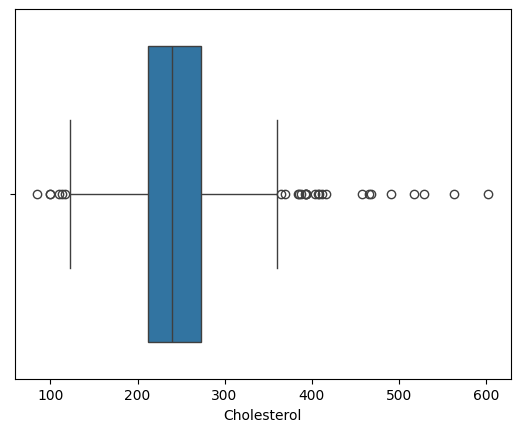

In [47]:
sns.boxplot(x = df["Cholesterol"], vert = False)

### Applying scalers to get rid of large values before it applying the encoding methods

In [48]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339.0,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207.0,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284.0,0,Normal,120,N,0.0,Up,0


In [49]:
encoding_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=encoding_cols, drop_first=True, dtype = int)
print(df_encoded.columns)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [50]:
df_encoded.head(15)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
5,39,120,339.0,0,170,0.0,0,1,0,1,0,1,0,0,0,1
6,45,130,237.0,0,170,0.0,0,0,1,0,0,1,0,0,0,1
7,54,110,208.0,0,142,0.0,0,1,1,0,0,1,0,0,0,1
8,37,140,207.0,0,130,1.5,1,1,0,0,0,1,0,1,1,0
9,48,120,284.0,0,120,0.0,0,0,1,0,0,1,0,0,0,1


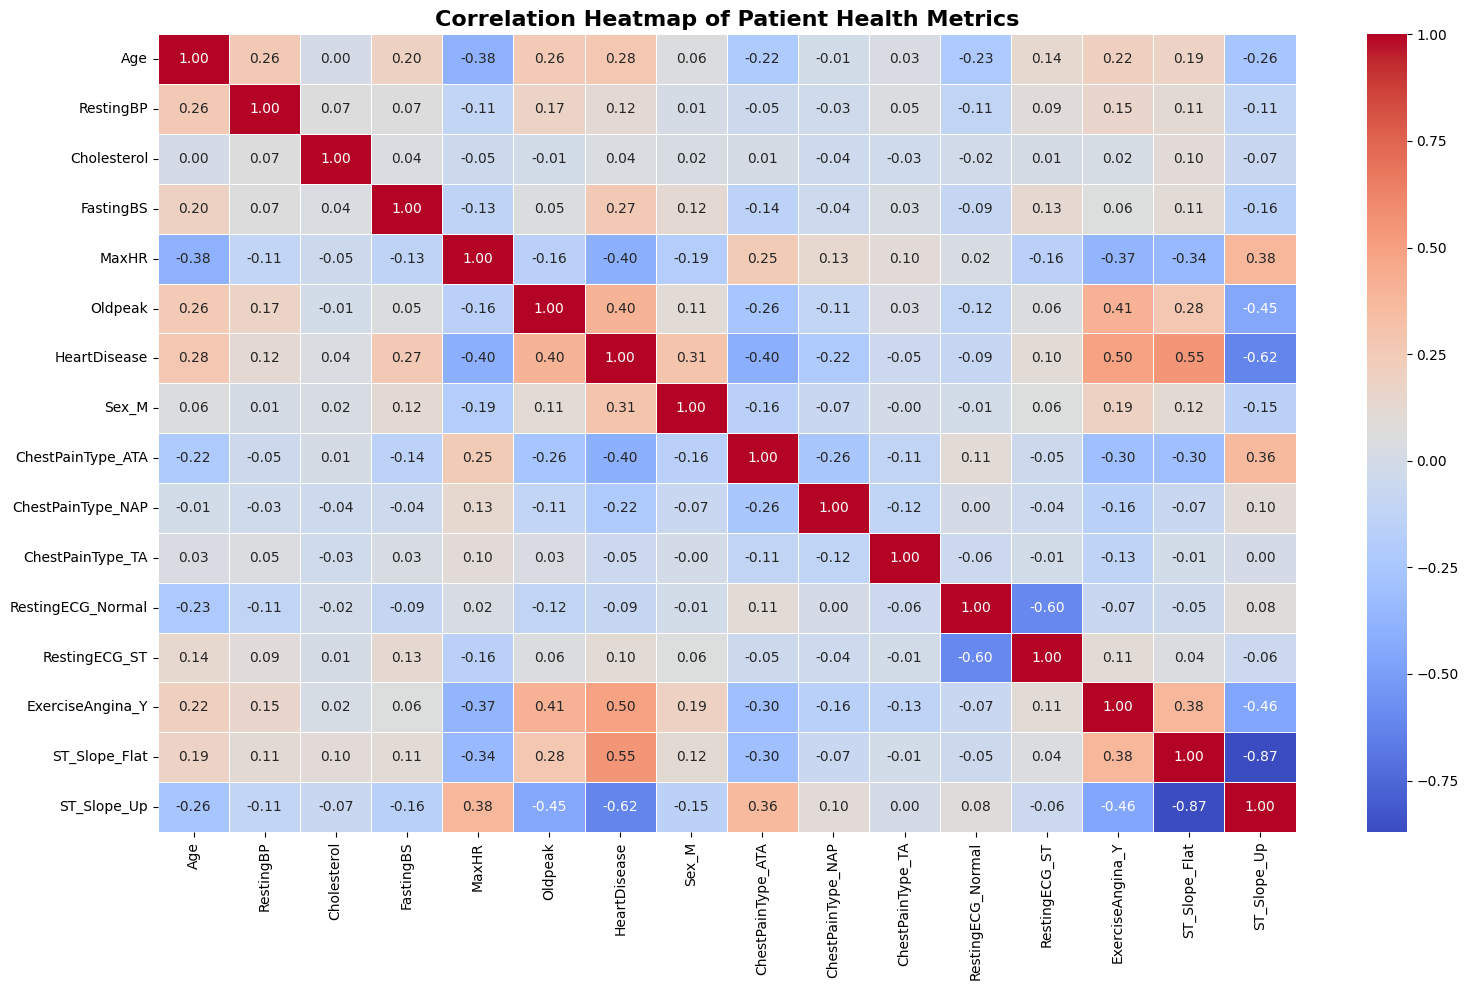

In [51]:
plt.figure(figsize=(16, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Patient Health Metrics", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Implementing Train Test and Split 

In [52]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

kf = StratifiedKFold(
    n_splits=7,
    shuffle=True,
    random_state=42
)

models_dict = {
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))
    ]),

    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=0.1,
            max_iter=1000
        ))
    ]),

    "Naïve Bayes": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    )
}   

for name, model in models_dict.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='accuracy'
    )

    print(f"\n{name}")
    print("Fold Scores:", scores)
    print(f"Average Score: {scores.mean():.4f}")
    print(f"Std Dev: {scores.std():.4f}")


KNN
Fold Scores: [0.84761905 0.84761905 0.79047619 0.9047619  0.85714286 0.875
 0.86538462]
Average Score: 0.8554
Std Dev: 0.0322

Logistic Regression
Fold Scores: [0.83809524 0.85714286 0.80952381 0.87619048 0.86666667 0.875
 0.84615385]
Average Score: 0.8527
Std Dev: 0.0220

Naïve Bayes
Fold Scores: [0.81904762 0.84761905 0.8        0.85714286 0.85714286 0.85576923
 0.81730769]
Average Score: 0.8363
Std Dev: 0.0219

Random Forest
Fold Scores: [0.83809524 0.82857143 0.76190476 0.87619048 0.8952381  0.875
 0.81730769]
Average Score: 0.8418
Std Dev: 0.0419


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8315217391304348
F1 Score: 0.8502415458937198
ROC-AUC: 0.9231229076996652


In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



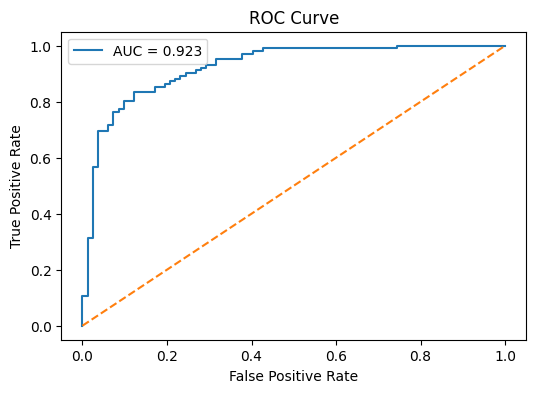

In [64]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [68]:
knn =  Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))])

In [69]:
knn


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=9))])